# Análise Inicial dos Dados – TelecomX Churn

Este notebook realiza uma análise exploratória inicial do dataset da TelecomX
com foco em entender a estrutura dos dados e identificar possíveis fatores
relacionados à evasão de clientes (churn).

Objetivos desta etapa:

- compreender a estrutura do dataset
- analisar a distribuição da variável churn
- identificar relações entre variáveis
- levantar hipóteses para a modelagem preditiva

In [27]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path().resolve().parents[0]))
from src.data.load_data import load_data

sns.set(style="whitegrid")

In [5]:
df = load_data()

df.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [6]:
df.shape

(7267, 21)

In [7]:
df.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   str    
 1   churn                      7043 non-null   str    
 2   customer_gender            7267 non-null   str    
 3   customer_seniorcitizen     7267 non-null   int64  
 4   customer_partner           7267 non-null   str    
 5   customer_dependents        7267 non-null   str    
 6   customer_tenure            7267 non-null   int64  
 7   phone_phoneservice         7267 non-null   str    
 8   phone_multiplelines        7267 non-null   str    
 9   internet_internetservice   7267 non-null   str    
 10  internet_onlinesecurity    7267 non-null   str    
 11  internet_onlinebackup      7267 non-null   str    
 12  internet_deviceprotection  7267 non-null   str    
 13  internet_techsupport       7267 non-null   str    
 14  int

In [9]:
df.describe()

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.describe(include="all")

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
count,7267,7043,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7256.000000
unique,7267,2,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,NaN
top,0002-ORFBO,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,NaN
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,2280.634213
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,2268.632997
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,400.225000
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,1391.000000
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,3785.300000


In [12]:
df["churn"].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["churn"].value_counts(normalize=True)

churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

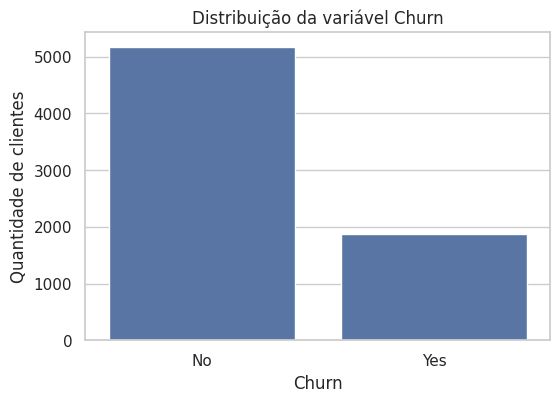

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="churn", data=df)

plt.title("Distribuição da variável Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de clientes")

plt.show()

In [15]:
numeric_df = df.select_dtypes(include=["number"])

In [16]:
corr = numeric_df.corr()

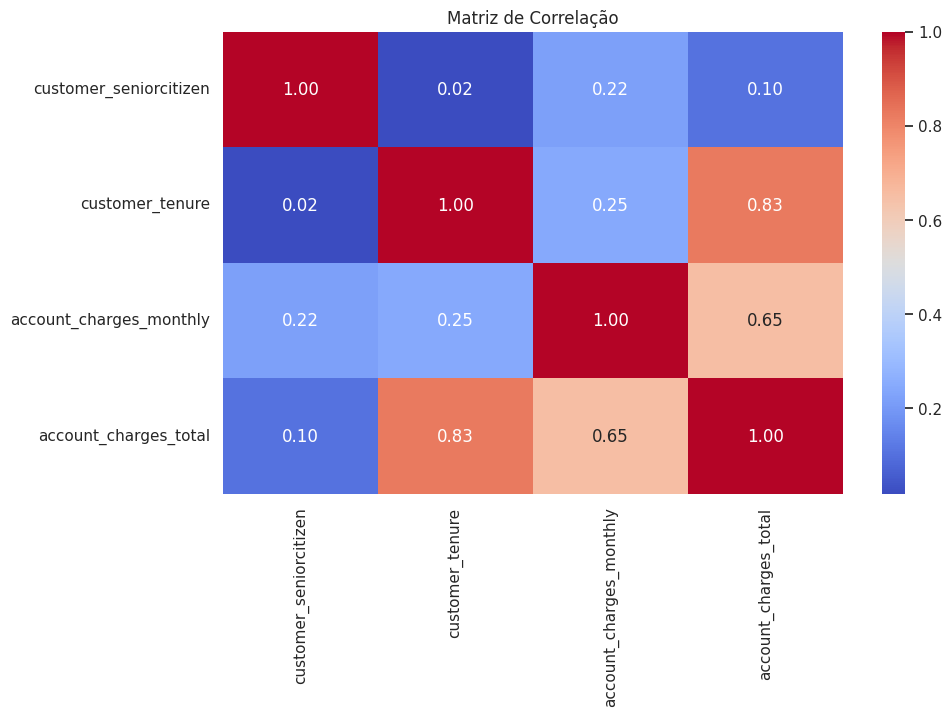

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")
plt.show()

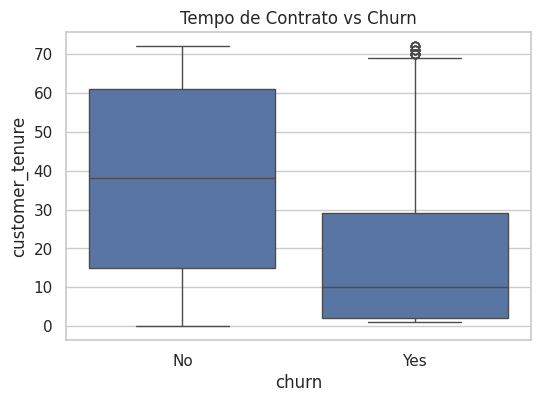

In [21]:
plt.figure(figsize=(6,4))

sns.boxplot(x="churn", y="customer_tenure", data=df)

plt.title("Tempo de Contrato vs Churn")
plt.show()

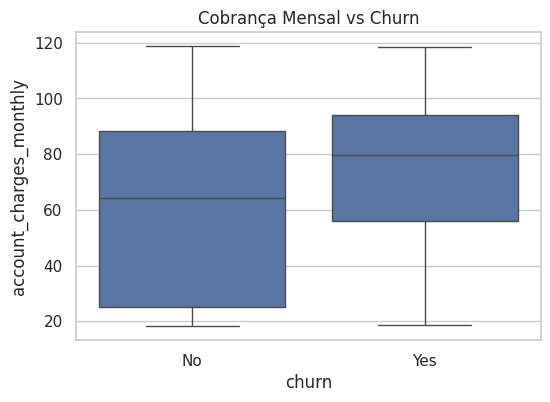

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(x="churn", y="account_charges_monthly", data=df)

plt.title("Cobrança Mensal vs Churn")
plt.show()

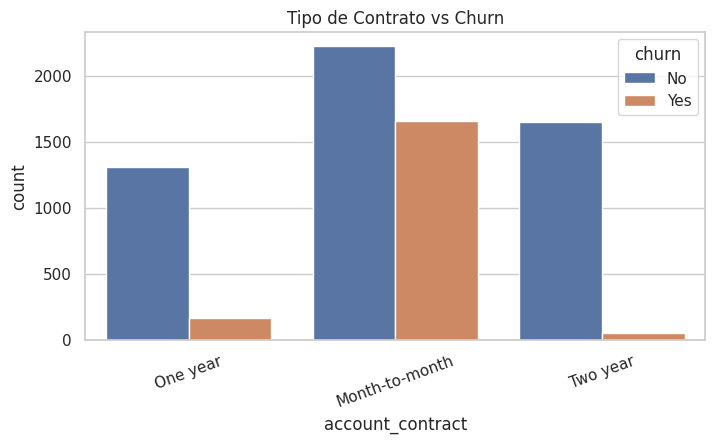

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(x="account_contract", hue="churn", data=df)

plt.title("Tipo de Contrato vs Churn")
plt.xticks(rotation=20)

plt.show()

## Conclusões iniciais

A análise exploratória inicial revelou alguns padrões importantes:

- clientes com menor tempo de contrato apresentam maior churn
- contratos mensais apresentam maior taxa de evasão
- clientes com maiores cobranças mensais tendem a cancelar mais

Esses fatores serão considerados nas próximas etapas do projeto,
quando os dados serão preparados para a construção de modelos
preditivos de churn.